# 1. 明确预测目标

## **场景** 
某中型电商平台需要预测未来30天的每日GMV，用于：
+ 制定合理的销售目标和营销预算
+ 优化库存管理和物流资源配置
+ 评估业务健康状况和增长潜力

## **数据约束**
+ 数据量：过去2年每日数据（730条记录）
+ 特征：GMV、订单量、访客数、转化率、营销活动、节假日等
+ 预测精度要求：平均绝对百分比误差（MAPE）< 8%

# 2. 数据准备&探索性分析

## 2.1 数据准备

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于显示中文
plt.rcParams['axes.unicode_minus'] = False    # 用于正常显示负号
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore') # 忽略警告信息，保持输出清晰

# 1.1 加载并生成模拟数据（实际场景中从数据库/数据仓库加载）
def generate_simulated_data():
    """生成模拟电商数据，包含趋势、季节性和节假日效应"""
    np.random.seed(42)
    date_range = pd.date_range('2022-01-01', '2024-12-31', freq='D')  # 生成日期序列
    n = len(date_range) # 总天数
    
    # 基础趋势：线性增长 + 周期性波动
    trend = np.linspace(100, 500, n)  # 从100万到500万的值（按天数均分）→ 模拟线性趋势
    seasonal = 50 * np.sin(2 * np.pi * np.arange(n) / 365)  # 横轴为0-4π的三角函数 → 模拟年季节性波动（波幅较大）
    weekly = 20 * np.sin(2 * np.pi * np.arange(n) / 7)  # 模拟周季节性波动（幅度较小）
    noise = np.random.normal(0, 15, n)  # 随机噪声
    
    # 生成GMV
    gmv = trend + seasonal + weekly + noise
    gmv = np.maximum(gmv, 50)  # 确保最小值为50万，避免负值
    
    # 生成行为特征
    visitors = gmv * 0.02 + np.random.normal(1000, 200, n)  # 访客数
    conversion_rate = 0.03 + 0.01 * np.sin(2 * np.pi * np.arange(n) / 30)  # 转化率波动
    orders = visitors * conversion_rate + np.random.normal(0, 50, n)  # 订单量
    
    # 创建数据表格
    df = pd.DataFrame({
        'date': date_range,
        'gmv': gmv,
        'visitors': visitors,
        'orders': orders,
        'conversion_rate': conversion_rate,
        'avg_order_value': gmv / orders  # 客单价
    })
    
    # 添加时间特征
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_year'] = df['date'].dt.dayofyear
    df['week_of_year'] = df['date'].dt.isocalendar().week
    df['quarter'] = df['date'].dt.quarter
    
    # 添加节假日标记（哑变量）
    holidays = {
        'spring_festival': ['2022-02-01', '2022-02-02', '2022-02-03',
                           '2023-01-22', '2023-01-23', '2023-01-24',
                           '2024-02-10', '2024-02-11', '2024-02-12'],
        'national_day': ['2022-10-01', '2022-10-02', '2022-10-03',
                        '2023-10-01', '2023-10-02', '2023-10-03',
                        '2024-10-01', '2024-10-02', '2024-10-03'],
        '618': ['2022-06-18', '2023-06-18', '2024-06-18'],
        'double_11': ['2022-11-11', '2023-11-11', '2024-11-11']
    }
    
    df['is_holiday'] = 0
    df['holiday_type'] = 'normal'
    
    for holiday, dates in holidays.items():  # 返回一个包含字典所有键值对的视图对象（dict_items），以 (key, value) 元组的形式展示每个键值对
        mask = df['date'].isin(pd.to_datetime(dates)) # 返回一个布尔数组，表示 df['date'] 中的每个元素是否在指定的日期列表中
        df.loc[mask, 'is_holiday'] = 1
        df.loc[mask, 'holiday_type'] = holiday
    
    # 添加营销活动标记（模拟）
    np.random.seed(42)
    df['has_promotion'] = np.random.choice([0, 1], n, p=[0.7, 0.3])  # 在0.1中随机抽样，命中概率分别为0.7和0.3 → 模拟30%的日子有促销活动
    df['promotion_intensity'] = np.random.uniform(0, 1, n) * df['has_promotion']
    
    # 添加外部特征（模拟）
    df['temperature'] = 15 + 20 * np.sin(2 * np.pi * df['day_of_year'] / 365) + np.random.normal(0, 5, n)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    return df

## 2.2 数据探索分析

=== 数据概览 ===
数据形状: (1096, 19)
时间范围: 2022-01-01 00:00:00 到 2024-12-31 00:00:00

=== 数据描述 ===
               gmv     visitors       orders  conversion_rate
count  1096.000000  1096.000000  1096.000000      1096.000000
mean    300.532761  1013.402928    30.782545         0.030087
std     114.272291   199.717084    50.932219         0.007071
min      71.509101   404.909916  -117.943045         0.020055
25%     187.931518   879.951745    -4.549103         0.022569
50%     300.564423  1010.205373    30.444811         0.030000
75%     416.749098  1143.054125    65.653520         0.037431
max     529.262195  1645.422603   230.743813         0.039945


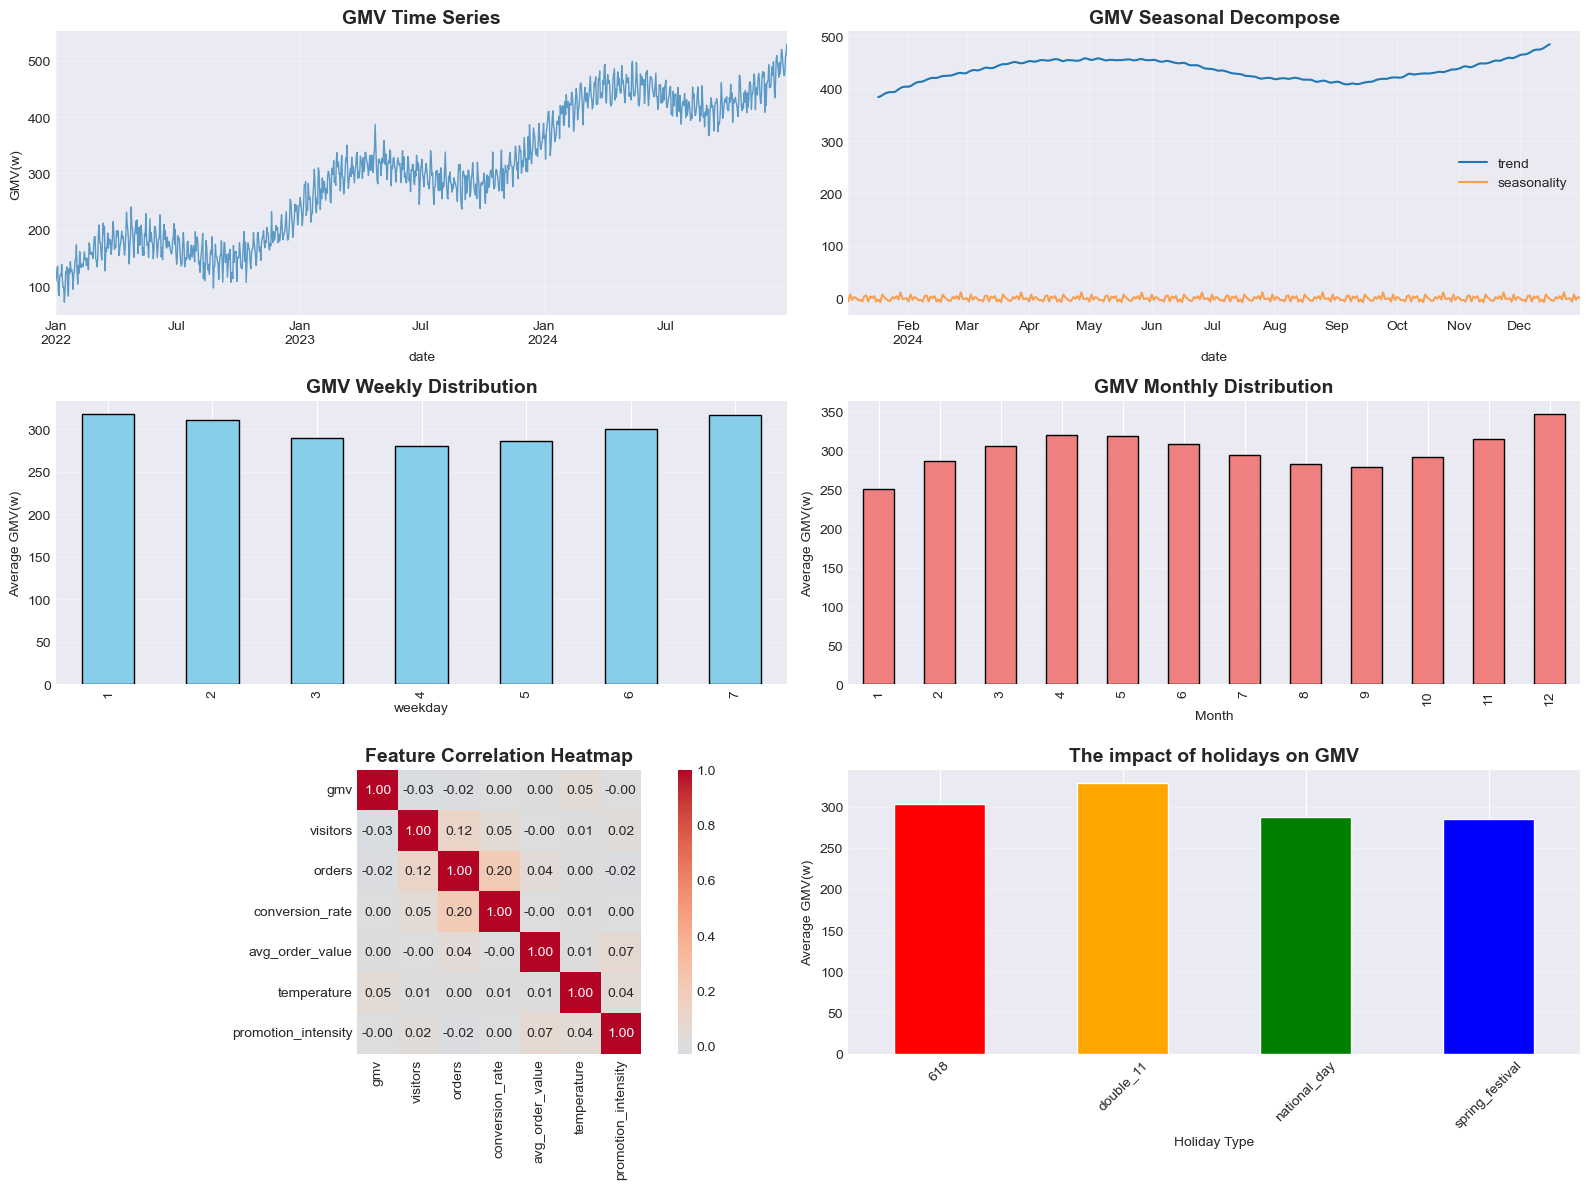


=== 关键业务指标 ===
GMV年复合增长率: 61.6%
月均GMV波动系数: 0.381


,date,gmv,visitors,orders,conversion_rate,avg_order_value,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_holiday,holiday_type,has_promotion,promotion_intensity,temperature,is_weekend
0,2022-01-01,107.450712,1017.876052,131.751763,0.030000,0.815554,2022,1,1,5,1,52,1,0,normal,0,0.000000,18.707136,1
1,2022-01-02,114.788630,602.655636,-48.826040,0.032079,-2.350972,2022,1,2,6,2,52,1,0,normal,1,0.186438,25.187842,1
2,2022-01-03,131.665561,1185.898846,49.885759,0.034067,2.639342,2022,1,3,0,3,1,1,0,normal,1,0.779584,15.369225,0
3,2022-01-04,135.199996,1072.001695,5.362010,0.035878,25.214425,2022,1,4,1,4,1,1,0,normal,0,0.000000,11.503402,0
4,2022-01-05,92.711333,1201.456249,66.266608,0.037431,1.399066,2022,1,5,2,5,1,1,0,normal,0,0.000000,22.254699,0
5,2022-01-06,83.114111,422.411207,17.287913,0.038660,4.807643,2022,1,6,3,6,1,1,0,normal,0,0.000000,16.460128,0
6,2022-01-07,115.398428,1419.982910,24.029982,0.039511,4.802269,2022,1,7,4,7,1,1,0,normal,0,0.000000,6.540813,0
7,2022-01-08,120.079001,974.483654,63.319577,0.039945,1.896396,2022,1,8,5,8,1,1,0,normal,1,0.927752,21.982684,1
8,2022-01-09,118.380827,1224.004180,139.110520,0.039945,0.850984,2022,1,9,6,9,1,1,0,normal,0,0.000000,15.409535,1
9,2022-01-10,138.640071,794.791616,21.857476,0.039511,6.342913,2022,1,10,0,10,2,1,0,normal,1,0.173895,17.973196,0


In [2]:
import math

def exploratory_data_analysis(df):
    """执行探索性数据分析"""
    print("=== 数据概览 ===")
    print(f"数据形状: {df.shape}")
    print(f"时间范围: {df['date'].min()} 到 {df['date'].max()}")
    print("\n=== 数据描述 ===")
    print(df[['gmv', 'visitors', 'orders', 'conversion_rate']].describe())
    
    # 设置可视化风格
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))  # 3*2的子图布局
    
    # 1. GMV时间序列趋势
    ax = axes[0, 0]  # 1行1列的子图对象
    df.set_index('date')['gmv'].plot(ax=ax, linewidth=1, alpha=0.7)  # 将日期列设置为行索引，绘图线宽设为 1、透明度设为 0.7
    ax.set_title('GMV Time Series', fontsize=14, fontweight='bold')
    ax.set_xlabel('date')
    ax.set_ylabel('GMV(w)')
    ax.grid(True, alpha=0.3)  # 添加网格线，透明度设为 0.3
    
    # 2. 季节性分解（简化版）
    ax = axes[0, 1]
    from statsmodels.tsa.seasonal import seasonal_decompose
    result = seasonal_decompose(df.set_index('date')['gmv'].iloc[-365:], 
                               model='additive', period=30)  # iloc取近365天数据（最后365行），加法模型（GMV=趋势+季节波动+残差），设定季节性周期为30天（需调试）
    result.trend.plot(ax=ax, label='trend')  # 长期趋势
    result.seasonal.plot(ax=ax, label='seasonality', alpha=0.7)  # 季节性波动
    ax.set_title('GMV Seasonal Decompose', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. 周内模式
    ax = axes[1, 0]
    weekly_pattern = df.groupby('day_of_week')['gmv'].mean()
    weekly_pattern.index = ['1', '2', '3', '4', '5', '6', '7']
    weekly_pattern.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')  # 柱状图，颜色设为天蓝色，边框颜色设为黑色
    ax.set_title('GMV Weekly Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('weekday')
    ax.set_ylabel('Average GMV(w)')
    ax.grid(True, alpha=0.3, axis='y')  # 仅显示y轴(水平)网格线
    
    # 4. 月度模式
    ax = axes[1, 1]
    monthly_pattern = df.groupby('month')['gmv'].mean()
    monthly_pattern.plot(kind='bar', ax=ax, color='lightcoral', edgecolor='black')
    ax.set_title('GMV Monthly Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Average GMV(w)')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 5. 特征相关性热力图
    ax = axes[2, 0]
    numeric_cols = ['gmv', 'visitors', 'orders', 'conversion_rate', 
                   'avg_order_value', 'temperature', 'promotion_intensity']
    corr_matrix = df[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, ax=ax, square=True)  # annot=true在热力图的每个单元格中显示数值， 'coolwarm': '冷暖色（蓝-白-红）'，center=0使颜色以0为中心 对称着色，square=True使每个单元格为正方形
    ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
    
    # 6. 节假日效应
    ax = axes[2, 1]
    holiday_effect = df.groupby('holiday_type')['gmv'].mean()
    holiday_effect = holiday_effect[holiday_effect.index != 'normal']
    holiday_effect.plot(kind='bar', ax=ax, color=['red', 'orange', 'green', 'blue'])
    ax.set_title('The impact of holidays on GMV', fontsize=14, fontweight='bold')
    ax.set_xlabel('Holiday Type')
    ax.set_ylabel('Average GMV(w)')
    ax.tick_params(axis='x', rotation=45)  # 旋转x轴标签以避免重叠
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()  # 调整子图间距
    plt.savefig('eda_results.png', dpi=300, bbox_inches='tight')  # 保存图像，dpi设为300以获得高分辨率，bbox_inches='tight'确保图像内容完整
    plt.show()
    
    # 计算关键统计指标
    print("\n=== 关键业务指标 ===")
    print(f"GMV年复合增长率: {(math.sqrt(df[df['year']==2024]['gmv'].mean() / df[df['year']==2022]['gmv'].mean()) - 1) * 100:.1f}%")
    print(f"月均GMV波动系数: {df.groupby(['year', 'month'])['gmv'].sum().std() / df.groupby(['year', 'month'])['gmv'].sum().mean():.3f}")  # 波动系数: 标准差/均值
    
    return df

# 生成并探索数据
df = generate_simulated_data()
df = exploratory_data_analysis(df)
df.head(10)

# 3. 特征工程&数据预处理

In [3]:
# 3.1 构建时间序列特征
def create_time_features(df, target_col='gmv', lags=[1, 3, 7, 14, 30], windows=[7, 14, 30]):
    """
    创建时间序列特征：滞后特征、滑动窗口统计特征
    """
    df_processed = df.copy()
    
    # 确保按日期排序
    df_processed = df_processed.sort_values('date').reset_index(drop=True)  # 按日期排序，并重置索引，drop=True表示丢弃原索引，避免添加新列
    
    # 滞后特征（Lag Features）
    print("创建滞后特征...")
    for lag in lags:
        df_processed[f'{target_col}_lag_{lag}'] = df_processed[target_col].shift(lag)  # shift函数用于创建滞后特征，lag表示滞后天数
        df_processed[f'visitors_lag_{lag}'] = df_processed['visitors'].shift(lag)
        df_processed[f'orders_lag_{lag}'] = df_processed['orders'].shift(lag)
    
    # 滑动窗口统计特征（Rolling Statistics）
    print("创建滑动窗口特征...")
    for window in windows:
        # 滚动均值
        df_processed[f'{target_col}_rolling_mean_{window}'] = df_processed[target_col].rolling(window=window, min_periods=1).mean().shift(1)  # rolling函数用于计算滑动窗口统计特征，window表示窗口大小，min_periods=1表示至少需要1个非NA值才能计算均值，shift(1)表示将结果向下移动一行，避免数据泄露 → 确保特征只使用历史数据，不shift的话数据会包含当日信息
        df_processed[f'{target_col}_rolling_std_{window}'] = df_processed[target_col].rolling(window=window, min_periods=1).std().shift(1)
        
        # 滚动最大值/最小值
        df_processed[f'{target_col}_rolling_max_{window}'] = df_processed[target_col].rolling(window=window, min_periods=1).max().shift(1)
        df_processed[f'{target_col}_rolling_min_{window}'] = df_processed[target_col].rolling(window=window, min_periods=1).min().shift(1)
        
        # 其他特征的滚动统计
        df_processed[f'visitors_rolling_mean_{window}'] = df_processed['visitors'].rolling(window=window, min_periods=1).mean().shift(1)
        df_processed[f'conversion_rate_rolling_mean_{window}'] = df_processed['conversion_rate'].rolling(window=window, min_periods=1).mean().shift(1)
    
    # 周同比/月同比特征
    df_processed[f'{target_col}_week_over_week'] = df_processed[target_col] / df_processed[f'{target_col}_lag_7']
    df_processed[f'{target_col}_month_over_month'] = df_processed[target_col] / df_processed[f'{target_col}_lag_30']
    
    
    # 距离节假日的天数
    print("创建节假日距离特征...")  
    holiday_dates = []
    # 将每种节假日的日期添加到holiday_dates列表中
    for holiday_type in ['spring_festival', 'national_day', '618', 'double_11']:
        holiday_dates.extend(df_processed[df_processed['holiday_type'] == holiday_type]['date'].tolist())   # tolist()方法将日期序列转换为列表，extend()方法将列表中的元素逐个添加到holiday_dates列表中
    
    holiday_dates = sorted(set(holiday_dates))  # 去重并排序节假日日期
    df_processed['days_to_next_holiday'] = np.nan
    df_processed['days_from_last_holiday'] = np.nan
    
    for i in range(len(df_processed)):
        current_date = df_processed.loc[i, 'date']  # 获取当前行的日期
        future_holidays = [d for d in holiday_dates if d > current_date]  # 获取未来的节假日日期列表
        past_holidays = [d for d in holiday_dates if d <= current_date]
        
        if future_holidays:
            df_processed.loc[i, 'days_to_next_holiday'] = (future_holidays[0] - current_date).days  # 计算距离下一个节假日的天数，future_holidays[0]是未来节假日列表中的第一个日期，即最近的未来节假日
        
        if past_holidays:
            df_processed.loc[i, 'days_from_last_holiday'] = (current_date - past_holidays[-1]).days
    
    
    # 填充缺失值（使用向前填充）
    df_processed = df_processed.fillna(method='ffill').fillna(method='bfill')  # fillna方法用于填充缺失值，method='ffill'表示使用前一个有效值进行填充，method='bfill'表示使用后一个有效值进行填充 → 先向前填充，再向后填充，确保所有缺失值都被填充
    
    print(f"特征工程完成，原始特征数: {len(df.columns)}，新特征数: {len(df_processed.columns)}")
    print(f"新增特征示例: {[col for col in df_processed.columns if col not in df.columns][:10]}")
    
    return df_processed

# 3.2 特征选择与预处理
def prepare_features_target(df_processed, target_col='gmv', test_size=30):
    """
    准备特征和目标变量，划分训练集和测试集
    """
    # 排除非特征列
    exclude_cols = ['date', target_col, 'holiday_type']
    feature_cols = [col for col in df_processed.columns if col not in exclude_cols]
    
    # 分离特征和目标
    X = df_processed[feature_cols]
    y = df_processed[target_col]
    
    # 按时间划分训练集和测试集（最后30天作为测试集）
    split_idx = len(df_processed) - test_size
    
    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]
    
    # 特征缩放（对数值特征）
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    
    # 识别数值特征和分类特征
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()  # select_dtypes方法用于选择特定数据类型的列，返回df子集；include=[np.number]表示选择数值类型的列
    categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()  # include=['object', 'category']表示选择字符串类型和分类类型的列
    
    print(f"数值特征数: {len(numeric_features)}")
    print(f"分类特征数: {len(categorical_features)}")
    
    # 创建预处理管道（ColumnTransformer 对象），对不同类型的数据列应用不同的转换
    preprocessor = ColumnTransformer(
        # (名称, 转换器, 特征列)
        transformers=[
            ('num', StandardScaler(), numeric_features), # StandardScaler用于对数值特征进行标准化处理，使其均值为0，标准差为1
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ])  # OneHotEncoder将分类变量转换为模型可以直接处理的数值格式-二进制向量，handle_unknown='ignore'表示在测试集出现训练集中未见过的类别时不会报错-遇到新类别时返回全0向量不报错，sparse_output=False表示输出密集数组（返回numpy数组而非稀疏矩阵，便于查看和调试）
    
    return X_train, X_test, y_train, y_test, preprocessor, feature_cols

# 执行特征工程
print("=== 开始特征工程 ===")
df_processed = create_time_features(df, target_col='gmv')

# 准备训练测试数据
X_train, X_test, y_train, y_test, preprocessor, feature_cols = prepare_features_target(
    df_processed, target_col='gmv', test_size=30
)

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")
print(f"特征维度: {len(feature_cols)}")

=== 开始特征工程 ===
创建滞后特征...
创建滑动窗口特征...
创建节假日距离特征...
特征工程完成，原始特征数: 19，新特征数: 56
新增特征示例: ['gmv_lag_1', 'visitors_lag_1', 'orders_lag_1', 'gmv_lag_3', 'visitors_lag_3', 'orders_lag_3', 'gmv_lag_7', 'visitors_lag_7', 'orders_lag_7', 'gmv_lag_14']
数值特征数: 53
分类特征数: 0
训练集大小: (1066, 53), 测试集大小: (30, 53)
特征维度: 53


# 4. 模型选择&训练

In [4]:
# 4.1 模型选择与基准模型
def train_baseline_models(X_train, X_test, y_train, y_test, preprocessor):
    """
    训练多个基线模型进行比较
    """
    from sklearn.linear_model import LinearRegression, Ridge, Lasso
    from sklearn.ensemble import RandomForestRegressor # 随机森林回归模型，基于决策树的集成方法，通过构建多个决策树并取平均来提高预测性能和减少过拟合
    from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
    import xgboost as xgb
    import lightgbm as lgb
    from sklearn.pipeline import Pipeline  # Pipeline类用于将多个数据处理步骤和模型训练步骤串联起来，形成一个完整的机器学习工作流，简化代码并避免数据泄露
    
    # 定义模型列表
    # 管道化处理：使用Pipeline封装，确保一致的数据处理
    models = {
        'Linear Regression': Pipeline([
            ('preprocessor', preprocessor), # 特征预处理
            ('regressor', LinearRegression()) # 选用模型
        ]),
        'Ridge Regression': Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', Ridge(alpha=1.0))  
            # L2正则化（特征高度相关时更稳定），α为正则化强度参数，默认值为1.0
            # alpha越大，正则化越强，系数趋于0
            # alpha越小，保留更多特征，=0时则为普通线性回归 
        ]),
        'Random Forest': Pipeline([ # 随机森林：适用于非线性关系和特征交互，具有内置的特征重要性评估功能（扛过拟合能力强，适合处理高维数据，通过随机抽样和特征采样提高泛化能力）,可处理噪声和异常值，缺点是模型较大，训练和预测时间较长
            ('preprocessor', preprocessor),
            ('regressor', RandomForestRegressor(
                n_estimators=100, # 决策树数量，越多效果通常越好，但计算成本增加
                random_state=42, # 随机种子
                n_jobs=-1, # 并行计算，-1表示使用所有可用的CPU核心
                max_depth=None,  # 树的最大深度，None表示不限制
                min_samples_split=2,  # 内部节点再划分所需最小样本数
                min_samples_leaf=1   # 叶子节点最少样本数
            )) 
        ]),  
        'XGBoost': Pipeline([ # 极限梯度提升树（Extreme Gradient Boosting）：基于梯度提升算法的高效实现(逐步修正前序树的残差)，内置L1、L2正则化，自动处理缺失值，可处理稀疏特征和高维数据，缺点是模型较大，训练时间较长，参数较多需要调优
            ('preprocessor', preprocessor),
            ('regressor', xgb.XGBRegressor(
                n_estimators=100, # 树的数量
                learning_rate=0.1, # 学习率/步长（控制每棵树的贡献）
                # learning_rate=0.1: 保守学习，需要更多树
                # learning_rate=0.3: 快速学习，可能不稳定
                max_depth=5, # 树的最大深度，控制模型复杂度
                random_state=42, # 随机种子
                n_jobs=-1, # 并行计算
                subsample=1.0,  # 每棵树使用的样本比例
                colsample_bytree=1.0,  # 每棵树使用的特征比例
                reg_alpha=0,  # L1正则化项
                reg_lambda=1   # L2正则化项
            ))
        ]),
        'LightGBM': Pipeline([  # Light Gradient Boosting Machine：基于梯度提升算法的高效实现，使用基于直方图的决策树算法，内置L1、L2正则化，自动处理缺失值，适合大规模数据和高维特征，处理大规模数据时速度更快，内存使用更少
            # 直方图算法：将连续特征离散化，加速训练，减少内存使用
            # leaf-wise生长：每次分裂增益最大的叶子优先分裂，通常比level-wise更快更准确，但可能过拟合（通过设置max_depth或min_child_samples控制）
            ('preprocessor', preprocessor),
            ('regressor', lgb.LGBMRegressor(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=5,
                random_state=42,
                n_jobs=-1,
                num_leaves=20,  # 叶子节点数，控制复杂度
                min_child_samples=10,  # 叶子节点最小样本数
                subsample=1.0,   # 行采样比例
                colsample_bytree=1.0, # 列采样比例
                reg_alpha=0.0,  # L1正则化
                reg_lambda=0.0,   # L2正则化
                verbosity=-1  # -1 表示只显示 Fatal 错误，隐藏 Warning 和 Info
            ))
        ])
    }
    
    # 训练并评估每个模型
    results = {}
    feature_importance_dict = {}
    
    for name, model in models.items():
        print(f"\n训练 {name}...")
        
        # 训练模型
        model.fit(X_train, y_train)
        
        # 预测
        y_pred_train = model.predict(X_train)  # 拟合程度
        y_pred_test = model.predict(X_test)  # 泛化能力
        
        # 计算评估指标
        train_mae = mean_absolute_error(y_train, y_pred_train)
        test_mae = mean_absolute_error(y_test, y_pred_test)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        train_mape = mean_absolute_percentage_error(y_train, y_pred_train)
        test_mape = mean_absolute_percentage_error(y_test, y_pred_test)
        
        # 保存结果
        results[name] = { # 键是模型名称，值是该模型的评估结果字典
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_mape': train_mape,
            'test_mape': test_mape,
            'model': model  # 训练好的模型对象(pipeline)，后续调优时可直接使用
        }
        
        print(f"{name} 结果:")
        print(f"  Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
        print(f"  Train RMSE: {train_rmse:.2f}, Test RMSE: {test_rmse:.2f}")
        print(f"  Train MAPE: {train_mape*100:.2f}%, Test MAPE: {test_mape*100:.2f}%")
        
        # 获取特征重要性（对于树模型）
        if hasattr(model.named_steps['regressor'], 'feature_importances_'): 
            importances = model.named_steps['regressor'].feature_importances_
            
            # 获取特征名称（需要考虑预处理后的特征）
            if hasattr(preprocessor, 'get_feature_names_out'):
                feature_names = preprocessor.get_feature_names_out()
            else:
                feature_names = feature_cols
            
            # 创建特征重要性DataFrame
            feature_importance = pd.DataFrame({
                'feature': feature_names[:len(importances)], # 确保特征名称数量与重要性数量匹配
                'importance': importances
            }).sort_values('importance', ascending=False).head(20)
            
            feature_importance_dict[name] = feature_importance 
            print(f"已保存 {name} 的特征重要性 ({len(feature_importance)} 个特征)")
    
    # 创建结果比较DataFrame
    results_df = pd.DataFrame(results).T
    return results_df, feature_importance_dict

# 4.2 模型调优（以LightGBM为例）
def optimize_lightgbm(X_train, X_test, y_train, y_test, preprocessor):
    """
    使用贝叶斯优化调优LightGBM超参数
    """
    from skopt import BayesSearchCV
    from skopt.space import Real, Integer, Categorical
    from sklearn.pipeline import Pipeline
    import lightgbm as lgb
    
    # 定义参数搜索空间
    search_spaces = {
        'regressor__n_estimators': Integer(50, 500), # 树的数量
        'regressor__learning_rate': Real(0.01, 0.3, prior='log-uniform'), # 学习率
        'regressor__max_depth': Integer(3, 10), # # 树的最大深度
        'regressor__num_leaves': Integer(20, 100), # 叶子节点数
        'regressor__min_child_samples': Integer(5, 50), # 叶子最小样本数
        'regressor__subsample': Real(0.6, 1.0), # 行采样比例
        'regressor__colsample_bytree': Real(0.6, 1.0), # 列采样比例
        'regressor__reg_alpha': Real(0, 1.0), # L1正则化
        'regressor__reg_lambda': Real(0, 1.0) # L2正则化
    }
    
    # 创建Pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', lgb.LGBMRegressor(random_state=42, n_jobs=-1))
    ])
    
    # 贝叶斯优化
    print("开始贝叶斯优化调参...")
    opt = BayesSearchCV(
        estimator=pipeline, # 要优化的模型
        search_spaces=search_spaces, # 参数搜索空间
        n_iter=30,  # 迭代次数
        cv=3,  # 交叉验证折数
        n_jobs=-1,
        random_state=42,
        scoring='neg_mean_absolute_error'  # 使用负MAE作为评估指标
    )
    
    # 执行优化
    opt.fit(X_train, y_train)
    
    print(f"最佳参数: {opt.best_params_}")
    print(f"最佳交叉验证分数: {-opt.best_score_:.2f}")
    
    # 使用最佳参数重新训练
    best_model = opt.best_estimator_
    
    # 在测试集上评估
    from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
    
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mape = mean_absolute_percentage_error(y_train, y_pred_train)
    test_mape = mean_absolute_percentage_error(y_test, y_pred_test)
    
    print("\n调优后模型性能:")
    print(f"Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    print(f"Train RMSE: {train_rmse:.2f}, Test RMSE: {test_rmse:.2f}")
    print(f"Train MAPE: {train_mape*100:.2f}%, Test MAPE: {test_mape*100:.2f}%")
    
    # 获取特征重要性（对于树模型）
    lightgbm_feature_importance = {}
    if hasattr(best_model.named_steps['regressor'], 'feature_importances_'): 
        importances = best_model.named_steps['regressor'].feature_importances_
        
        # 获取特征名称（需要考虑预处理后的特征）
        if hasattr(preprocessor, 'get_feature_names_out'):
            feature_names = preprocessor.get_feature_names_out()
        else:
            feature_names = feature_cols
        
        # 创建特征重要性DataFrame
        feature_importance = pd.DataFrame({
            'feature': feature_names[:len(importances)], 
            'importance': importances
        }).sort_values('importance', ascending=False)
        
         # 计算百分比（基于所有特征）
        total_importance = feature_importance['importance'].sum()   
        feature_importance['importance_percent_all'] = (feature_importance['importance'] / total_importance * 100)
        
        # 取前10个特征
        feature_importance_top = feature_importance.head(10).reset_index(drop=True)
        
    print("\n获取特征重要性")
    print(feature_importance_top[['feature','importance_percent_all']].applymap(lambda x: f"{x:.2f}%" if isinstance(x, (int, float)) else x))    
    return best_model, opt.best_params_

# 训练基线模型并比较
print("\n=== 训练基线模型 ===")
baseline_results, feature_importance_dict = train_baseline_models(
    X_train, X_test, y_train, y_test, preprocessor
)

# 选择最佳模型进行调优
print("\n=== 调优最佳模型 (LightGBM) ===")
best_model, best_params = optimize_lightgbm(X_train, X_test, y_train, y_test, preprocessor)


=== 训练基线模型 ===

训练 Linear Regression...
Linear Regression 结果:
  Train MAE: 6.22, Test MAE: 7.99
  Train RMSE: 8.33, Test RMSE: 10.16
  Train MAPE: 2.52%, Test MAPE: 1.65%

训练 Ridge Regression...
Ridge Regression 结果:
  Train MAE: 6.27, Test MAE: 7.61
  Train RMSE: 8.38, Test RMSE: 9.74
  Train MAPE: 2.54%, Test MAPE: 1.57%

训练 Random Forest...
Random Forest 结果:
  Train MAE: 2.40, Test MAE: 15.73
  Train RMSE: 3.41, Test RMSE: 19.71
  Train MAPE: 1.04%, Test MAPE: 3.17%
已保存 Random Forest 的特征重要性 (20 个特征)

训练 XGBoost...
XGBoost 结果:
  Train MAE: 1.10, Test MAE: 14.10
  Train RMSE: 1.44, Test RMSE: 18.07
  Train MAPE: 0.44%, Test MAPE: 2.82%
已保存 XGBoost 的特征重要性 (20 个特征)

训练 LightGBM...
LightGBM 结果:
  Train MAE: 1.42, Test MAE: 14.01
  Train RMSE: 1.89, Test RMSE: 18.22
  Train MAPE: 0.58%, Test MAPE: 2.80%
已保存 LightGBM 的特征重要性 (20 个特征)

=== 调优最佳模型 (LightGBM) ===
开始贝叶斯优化调参...
最佳参数: OrderedDict([('regressor__colsample_bytree', 0.6521647357739374), ('regressor__learning_rate', 0.1100271225687995

# 5. 模型效果评估


=== 执行综合模型评估 ===
=== 模型性能评估 ===
MAE (Train): 0.2762
MAE (Test): 16.6765
RMSE (Train): 1.0465
RMSE (Test): 20.5048
MAPE % (Train): 0.1035
MAPE % (Test): 3.3515
WAPE % (Train): 0.0935
WAPE % (Test): 3.4360


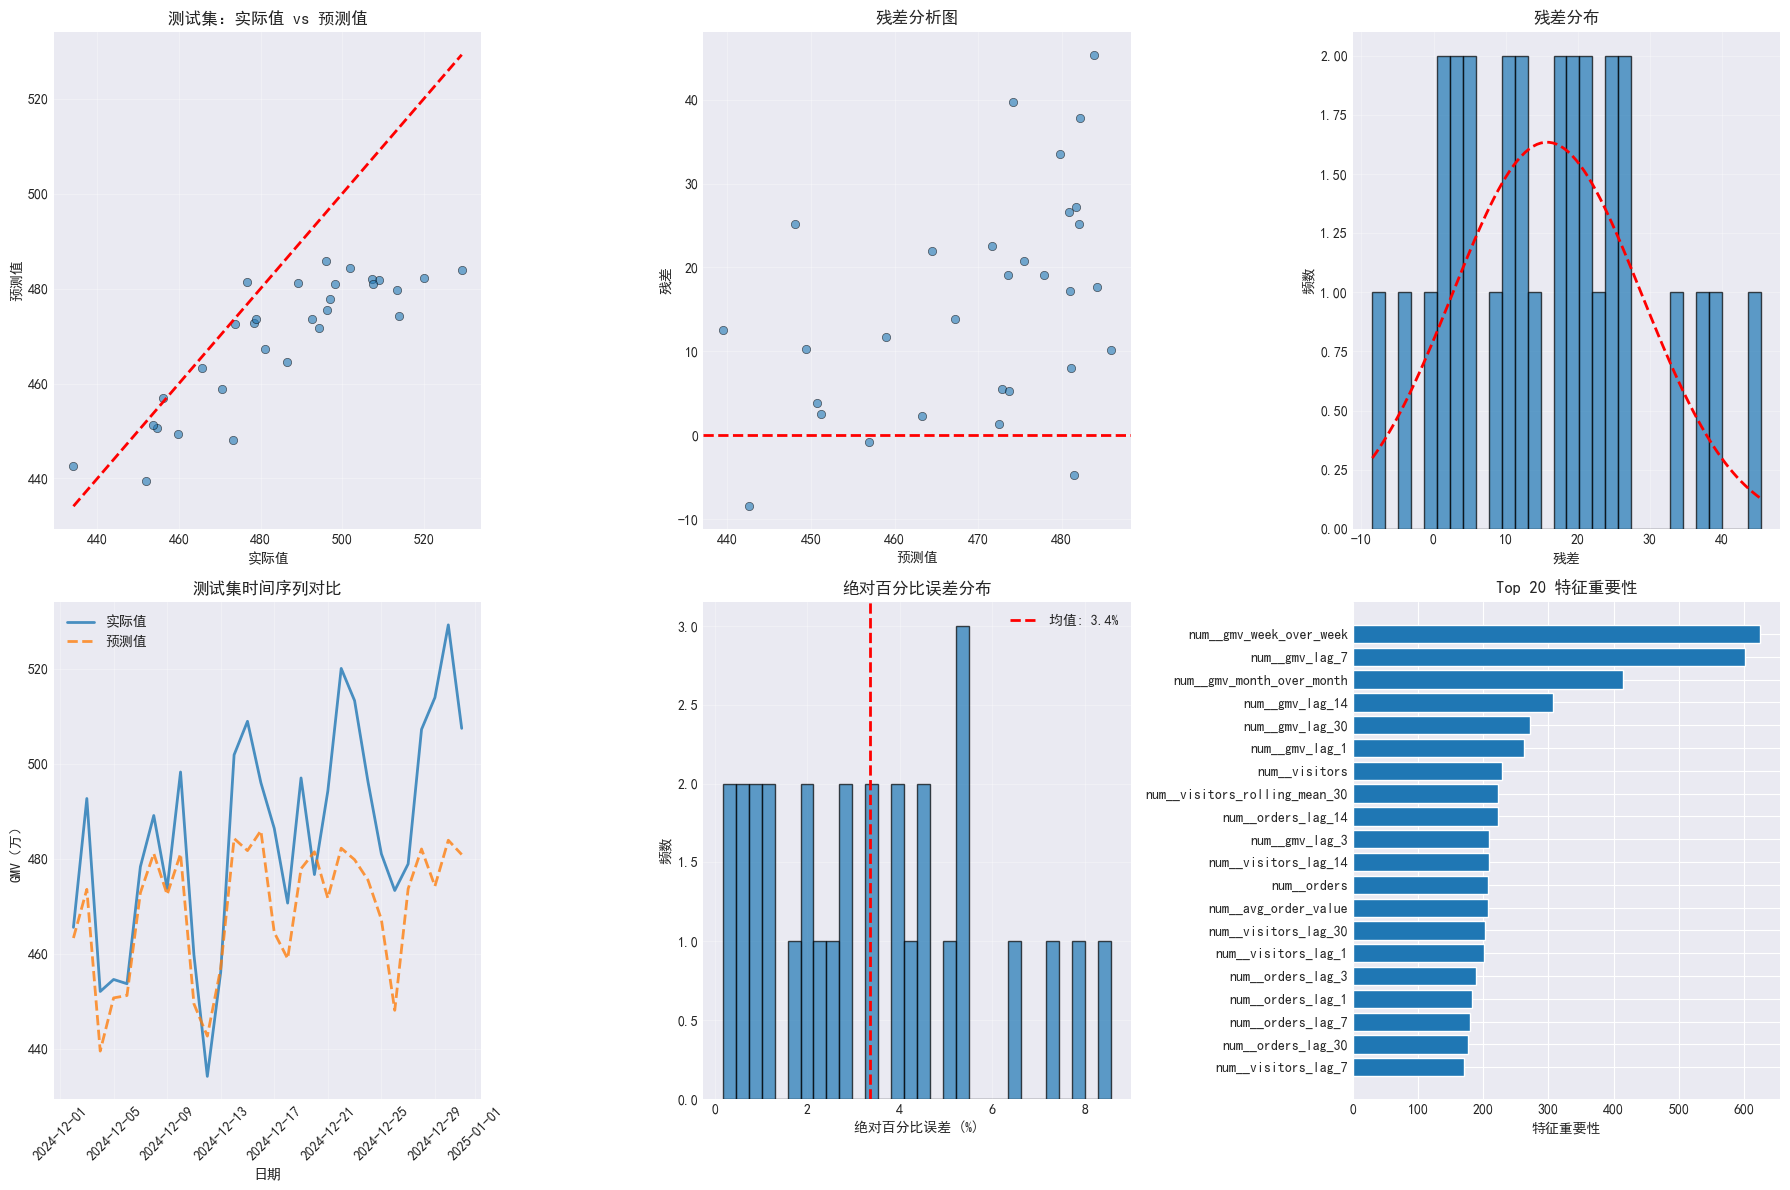


=== 时间序列交叉验证 ===
Fold 1: 
    训练集：0 - 915 (916 天)
    测试集：916 - 945 (30 天)
    MAE=7.46, MAPE=1.78%, RMSE=9.31
Fold 2: 
    训练集：0 - 945 (946 天)
    测试集：946 - 975 (30 天)
    MAE=5.09, MAPE=1.23%, RMSE=6.42
Fold 3: 
    训练集：0 - 975 (976 天)
    测试集：976 - 1005 (30 天)
    MAE=6.36, MAPE=1.59%, RMSE=8.09
Fold 4: 
    训练集：0 - 1005 (1006 天)
    测试集：1006 - 1035 (30 天)
    MAE=4.11, MAPE=0.95%, RMSE=5.37
Fold 5: 
    训练集：0 - 1035 (1036 天)
    测试集：1036 - 1065 (30 天)
    MAE=4.77, MAPE=1.07%, RMSE=5.98

平均性能:
平均 MAE: 5.56 (±1.20)
平均 MAPE: 1.32% (±0.32%)
平均 RMSE: 7.03 (±1.45)

=== 业务角度评估 ===
方向预测准确率: 79.3%
平均预测偏差: -3.1% (正值表示高估，负值表示低估)


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体
plt.rcParams['axes.unicode_minus'] = False   # 正常显示负号

# 5.1 综合模型评估
def comprehensive_model_evaluation(model, X_train, X_test, y_train, y_test, df_processed):
    """
    综合评估模型性能
    """
    from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
    import matplotlib.pyplot as plt
    import numpy as np
    import math
    from scipy.stats import norm
    
    # 预测
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # 计算多种评估指标
    metrics = {
        'MAE (Train)': mean_absolute_error(y_train, y_pred_train),
        'MAE (Test)': mean_absolute_error(y_test, y_pred_test),
        'RMSE (Train)': math.sqrt(mean_squared_error(y_train, y_pred_train)),
        'RMSE (Test)': math.sqrt(mean_squared_error(y_test, y_pred_test)),
        'MAPE % (Train)': mean_absolute_percentage_error(y_train, y_pred_train) * 100,
        'MAPE % (Test)': mean_absolute_percentage_error(y_test, y_pred_test) * 100
    }
    
    # 计算WAPE（加权平均绝对百分比误差）
    def wape(y_true, y_pred):
        return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
    
    metrics['WAPE % (Train)'] = wape(y_train, y_pred_train) * 100
    metrics['WAPE % (Test)'] = wape(y_test, y_pred_test) * 100
    
    print("=== 模型性能评估 ===")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    
    # 可视化评估结果
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. 实际值 vs 预测值（测试集）
    ax = axes[0, 0]
    ax.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='black', linewidth=0.5)  # 散点图  
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # 添加y=x参考线 → x轴起点到终点(y预测值的最小值到最大值)，y轴同理，红色虚线，线宽为2
    ax.set_xlabel('实际值')
    ax.set_ylabel('预测值')
    ax.set_title('测试集：实际值 vs 预测值')
    ax.grid(True, alpha=0.3)
    
    # 2. 残差分析
    ax = axes[0, 1]
    residuals = y_test - y_pred_test
    ax.scatter(y_pred_test, residuals, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax.set_xlabel('预测值')
    ax.set_ylabel('残差')
    ax.set_title('残差分析图')
    ax.grid(True, alpha=0.3)
    
    # 3. 残差分布
    ax = axes[0, 2]
    ax.hist(residuals, bins=30, edgecolor='black', alpha=0.7)  # bins=30: 直方图的柱子数量/分箱数
    ax.set_xlabel('残差')
    ax.set_ylabel('频数')
    ax.set_title('残差分布')
    ax.grid(True, alpha=0.3)
    
    # 添加正态分布曲线对比
    mu, std = norm.fit(residuals)
    x = np.linspace(residuals.min(), residuals.max(), 100) # 生成残差范围内的100个点
    p = norm.pdf(x, mu, std) 
    ax.plot(x, p * len(residuals) * (residuals.max() - residuals.min()) / 30, 
            'r--', linewidth=2, label='正态分布')  # 某区间内的样本数(频数) = 该区间下pdf面积(频率)×总样本数 = pdf×分箱宽度(组距)×总样本数  → pdf是单位长度的概率，可以>1
    
    
    # 4. 时间序列预测对比
    ax = axes[1, 0]
    test_dates = df_processed['date'].iloc[-len(y_test):]
    ax.plot(test_dates, y_test.values, label='实际值', linewidth=2, alpha=0.8) # y_test.values将pandas Series转换为numpy数组，确保与test_dates对齐，避免索引问题
    ax.plot(test_dates, y_pred_test, label='预测值', linewidth=2, alpha=0.8, linestyle='--')
    ax.set_xlabel('日期')
    ax.set_ylabel('GMV（万）')
    ax.set_title('测试集时间序列对比')
    ax.legend()
    ax.grid(True, alpha=0.3)
    # plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)  # Set Property 批处理函数，一次性修改一组对象的属性，ax.xaxis.get_majorticklabels()获取x轴主刻度标签列表，rotation=45设置旋转角度为45度
    ax.tick_params(axis='x', rotation=45)
    
    # 5. 绝对百分比误差分布
    ax = axes[1, 1]
    error_percentages = np.abs((y_test - y_pred_test) / y_test) * 100  # 绝对百分比误差
    ax.hist(error_percentages, bins=30, edgecolor='black', alpha=0.7)  # 直方图
    ax.axvline(x=error_percentages.mean(), color='r', linestyle='--', linewidth=2, label=f'均值: {error_percentages.mean():.1f}%')
    ax.set_xlabel('绝对百分比误差 (%)')
    ax.set_ylabel('频数')
    ax.set_title('绝对百分比误差分布')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. 特征重要性（如果可用）
    ax = axes[1, 2]
    if hasattr(model.named_steps['regressor'], 'feature_importances_'):
        importances = model.named_steps['regressor'].feature_importances_
        
        # 获取特征名称
        if hasattr(preprocessor, 'get_feature_names_out'):
            feature_names = preprocessor.get_feature_names_out()
        else:
            feature_names = feature_cols
        
        # 取前20个重要特征
        feature_importance_df = pd.DataFrame({
            'feature': feature_names[:len(importances)],
            'importance': importances
        }).sort_values('importance', ascending=False).head(20)
        
        # 绘制水平条形图
        ax.barh(range(len(feature_importance_df)), # 确定条形的垂直位置（y轴坐标）
                feature_importance_df['importance'].values, # 条形的长度（x轴数值）
                align='center')
        ax.set_yticks(range(len(feature_importance_df)))  # 确保每一行都有一个对应的刻度点
        ax.set_yticklabels(feature_importance_df['feature'].values)  # 将 y 轴的数字刻度替换为特征名称
        ax.set_xlabel('特征重要性')
        ax.set_title('Top 20 特征重要性')
        ax.invert_yaxis()  # 重要性从高到低显示
    
    plt.tight_layout()
    plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return metrics, y_pred_test

# 5.2 时间序列交叉验证
def time_series_cross_validation(model, X, y, n_splits=5, test_size=30):  
    # n_splits 交叉验证折数，test_size 每折测试集大小（天数）→ 每次预测未来30天的数据
    """
    时间序列交叉验证，防止数据泄露
    """
    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
    
    # 初始化时间序列交叉验证器
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    
    cv_scores = {'MAE': [], 'MAPE': [], 'RMSE': []}
    
    print("\n=== 时间序列交叉验证 ===")
    # 遍历每一折
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
        y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]
        
        # 训练模型
        model.fit(X_train_cv, y_train_cv)
        
        # 预测
        y_pred_cv = model.predict(X_test_cv)
        
        # 计算指标
        mae = mean_absolute_error(y_test_cv, y_pred_cv)
        mape = mean_absolute_percentage_error(y_test_cv, y_pred_cv)
        rmse = np.sqrt(mean_squared_error(y_test_cv, y_pred_cv))
        
        cv_scores['MAE'].append(mae)
        cv_scores['MAPE'].append(mape)
        cv_scores['RMSE'].append(rmse)
        
        print(f"Fold {fold}: ")
        print(f"    训练集：{X_train_cv.index.min()} - {X_train_cv.index.max()} ({len(X_train_cv)} 天)")
        print(f"    测试集：{X_test_cv.index.min()} - {X_test_cv.index.max()} ({len(X_test_cv)} 天)")
        print(f"    MAE={mae:.2f}, MAPE={mape*100:.2f}%, RMSE={rmse:.2f}")  
        # 关注最差的一折，分析该时段特点
    
    # 计算平均指标
    print(f"\n平均性能:")
    print(f"平均 MAE: {np.mean(cv_scores['MAE']):.2f} (±{np.std(cv_scores['MAE']):.2f})")
    print(f"平均 MAPE: {np.mean(cv_scores['MAPE'])*100:.2f}% (±{np.std(cv_scores['MAPE'])*100:.2f}%)")
    print(f"平均 RMSE: {np.mean(cv_scores['RMSE']):.2f} (±{np.std(cv_scores['RMSE']):.2f})")
    
    return cv_scores  # 返回包含每折评估指标的字典

# 执行综合评估
print("\n=== 执行综合模型评估 ===")
metrics, y_pred_test = comprehensive_model_evaluation(
    best_model, X_train, X_test, y_train, y_test, df_processed
)

# 时间序列交叉验证
cv_scores = time_series_cross_validation(
    best_model, X_train, y_train, n_splits=5, test_size=30
)

# 业务角度评估
print("\n=== 业务角度评估 ===")
                                                      
# 计算方向准确性（预测增长/下降方向是否正确）
def direction_accuracy(y_true, y_pred):
    direction_true = np.sign(np.diff(y_true))
    direction_pred = np.sign(np.diff(y_pred))
    matches = (direction_true == direction_pred).sum()
    return matches / len(direction_true) * 100

direction_acc = direction_accuracy(y_test.values, y_pred_test)
print(f"方向预测准确率: {direction_acc:.1f}%")

# 计算高估/低估偏差
bias_percentage = ((y_pred_test - y_test.values) / y_test.values).mean() * 100
print(f"平均预测偏差: {bias_percentage:.1f}% (正值表示高估，负值表示低估)")

# 6. 模型部署&监控

In [15]:
# 6.1 模型保存与版本管理
import joblib # 机器学习模型序列化，比pickle更适合保存numpy数组
import json # JSON格式保存元数据
from datetime import datetime
import os # 操作系统接口，处理目录和文件

def save_model_pipeline(model, feature_cols, metrics, version='1.0'):
    """
    保存完整的模型管道和元数据
    -----------
    参数：
    model: 训练好的机器学习Pipeline(预处理+模型)
    feature_cols: 特征列名列表
    metrics: 模型评估指标字典
    version: 模型版本号
    -----------
    返回:
    dict: 保存的文件路径信息
    """
    # 创建模型保存目录
    model_dir = f"models/v{version}"
    os.makedirs(model_dir, exist_ok=True)  # exist_ok=True表示如果目录已存在也不报错
    
    # 1. 保存模型文件
    model_path = os.path.join(model_dir, 'gmv_forecast_model.pkl')
    joblib.dump(model, model_path)  
    
    # 2. 保存特征列表
    features_path = os.path.join(model_dir, 'features.json')
    feature_data = {
        "feature_columns": list(feature_cols),
        "count": len(feature_cols)
    }
    with open(features_path, 'w', encoding='utf-8') as f:
        json.dump(feature_data, f, indent=4, ensure_ascii=False)  # indent=4美化输出，ensure_ascii=False允许中文字符正常保存
        
    # 3. 保存模型指标和版本信息
    # 存储模型表现、版本号及保存时间
    metrics_path = os.path.join(model_dir, 'metrics.json')
    performance_data = {
        "version": version,
        "metrics": metrics,
        "saved_at": datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    with open(metrics_path, 'w', encoding='utf-8') as f:
        json.dump(performance_data, f, indent=4, ensure_ascii=False)

    print(f"📦 版本 v{version} 保存成功：模型、特征列表与指标已分离")
    
    return {
        "model": model_path,
        "features": features_path,
        "metrics": metrics_path
    }

# 执行保存
gmv_forecast_model = save_model_pipeline(best_model, feature_cols, metrics, version='1.0')

# 模型调用
model = joblib.load(gmv_forecast_model['model'])  # 加载模型
with open(gmv_forecast_model['features'], 'r') as f:  # 加载特征列表
    features = json.load(f)['feature_columns']
    
# 进行预测
predictions = model.predict(X_test[features])

📦 版本 v1.0 保存成功：模型、特征列表与指标已分离
